<div class="alert alert-block alert-success">
<b>Comentario general del revisor</b> <a class="tocSkip"></a><br />
Status del proyecto: <b>Aprobado</b>
</div>


¡Hola!<br />
Soy **Francisco Cortés**, estoy contento de revisar tu proyecto y ser parte de tu proceso de aprendizaje.
A lo largo del texto, haré algunas observaciones sobre mejoras en el código y también haré comentarios sobre tus percepciones sobre el tema. Si existe algún error en el código, no te preocupes, estoy aquí para ayudarte a mejorarlo, en la primera iteración te lo señalaré para que tengas la oportunidad de corregirlo, pero si aún no encuentras una solución para esta tarea, te daré una pista más precisa en la próxima iteración y también algunos ejemplos prácticos. Estaré abierto a retroalimentación y discusiones sobre el tema.<br />
Encontrarás mis comentarios a continuación - **por favor no los muevas, modifiques o borres**.
Revisaré cuidadosamente tu código para comprobar que se han cumplido con los requisitos y te proporcionaré mis comentarios en cajas verdes, amarillas o rojas como esta:

<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a>

Si la ejecución fue perfecta succesfully.
</div>

<div class="alert alert-block alert-warning">
<b>Comentario del revisor</b> <a class="tocSkip"></a>

Si existe alguna recomendación para que tu código mejore.
</div>

<div class="alert alert-block alert-danger">

<b>Comentario del revisor</b> <a class="tocSkip"></a>

Si existen correcciones necesarias para cumplir con los requisitos. El trabajo no puede ser aceptado si hay alguna caja roja.
</div>

Puedes responderme de la siguiente manera:

<div class="alert alert-block alert-info">
<b>Respuesta del estudiante.</b> <a class="tocSkip"></a>
</div>

Importar las librerias

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind

Cargar el archivo

In [7]:
'''
df_trips = pd.read_csv('moved_project_sql_result_04.csv')
df_companies = pd.read_csv('moved_project_sql_result_01.csv')
df = pd.read_csv('moved_project_sql_result_07.csv')
'''
df_trips = pd.read_csv ('/datasets/project_sql_result_04.csv') 
df_companies = pd.read_csv ('/datasets/project_sql_result_01.csv')
df = pd.read_csv ('/datasets/project_sql_result_07.csv')

observamos el contenido de los dataframe

In [8]:
print(df_trips.head())
print(df_trips.dtypes)

  dropoff_location_name  average_trips
0                  Loop   10727.466667
1           River North    9523.666667
2         Streeterville    6664.666667
3             West Loop    5163.666667
4                O'Hare    2546.900000
dropoff_location_name     object
average_trips            float64
dtype: object


In [9]:
print(df_companies.head())
print(df_companies.dtypes)

                      company_name  trips_amount
0                        Flash Cab         19558
1        Taxi Affiliation Services         11422
2                Medallion Leasing         10367
3                       Yellow Cab          9888
4  Taxi Affiliation Service Yellow          9299
company_name    object
trips_amount     int64
dtype: object


mejores empresas con numero de viajes

In [10]:
top_10_companies = df_companies.sort_values(by='trips_amount', ascending=False).head(10)

In [11]:
print(top_10_companies)

                        company_name  trips_amount
0                          Flash Cab         19558
1          Taxi Affiliation Services         11422
2                  Medallion Leasing         10367
3                         Yellow Cab          9888
4    Taxi Affiliation Service Yellow          9299
5          Chicago Carriage Cab Corp          9181
6                       City Service          8448
7                           Sun Taxi          7701
8          Star North Management LLC          7455
9  Blue Ribbon Taxi Association Inc.          5953


Top 10 barrios con mayor numero de viajes

In [12]:
top_10_trips = df_trips.sort_values(by='average_trips', ascending=False).head(10)
print(top_10_trips)

  dropoff_location_name  average_trips
0                  Loop   10727.466667
1           River North    9523.666667
2         Streeterville    6664.666667
3             West Loop    5163.666667
4                O'Hare    2546.900000
5             Lake View    2420.966667
6            Grant Park    2068.533333
7         Museum Campus    1510.000000
8            Gold Coast    1364.233333
9    Sheffield & DePaul    1259.766667


Grafico numero de viajes por empresa de taxis

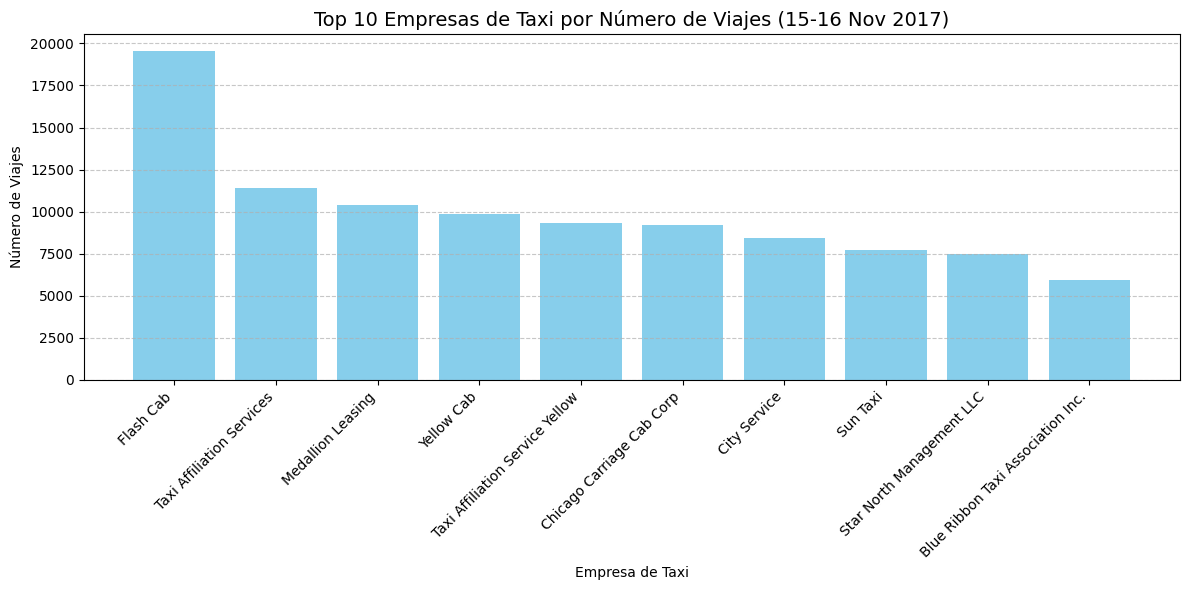

In [13]:
plt.figure(figsize=(12, 6))
plt.bar(top_10_companies['company_name'], top_10_companies['trips_amount'], color='skyblue')
plt.xticks(rotation=45, ha='right')
plt.title('Top 10 Empresas de Taxi por Número de Viajes (15-16 Nov 2017)', fontsize=14)
plt.xlabel('Empresa de Taxi')
plt.ylabel('Número de Viajes')
plt.tight_layout()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

Conclusion grafico 1: hay una notorio dominion de una empresa de taxi que es flash cap y todas las demas tienen una lucha muy pareja por la cuota de mercado que resta del gran dominio que tiene flash cap

<div class="alert alert-block alert-success"> <b>Comentario del revisor</b> <a class="tocSkip"></a><br>

Correcto!<br/>

Buena manera de mostrar el resultado, se puede observar la compañía que tiene más viajes agendados gracias a que limitaste el numero de compañías a mostrar
</div>

Grafico de los 10 barrios principales

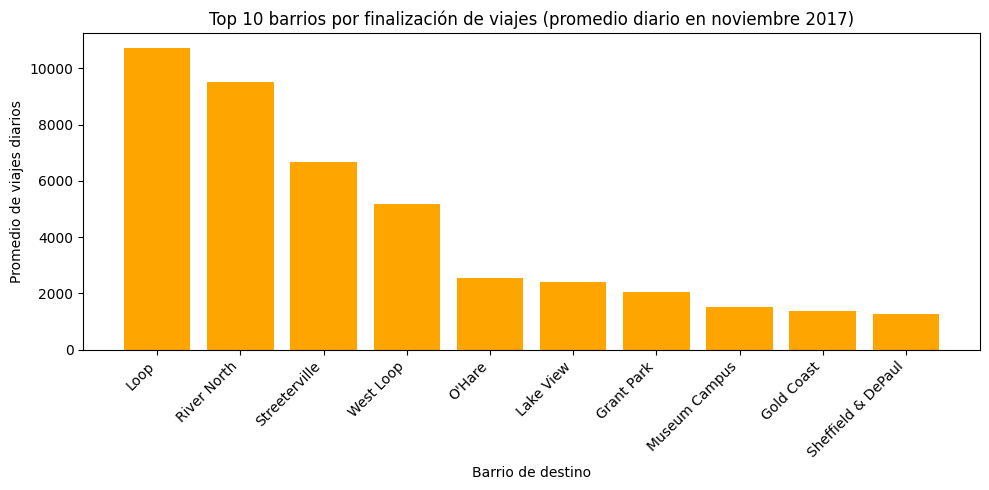

In [14]:
plt.figure(figsize=(10, 5))
plt.bar(top_10_trips['dropoff_location_name'], top_10_trips['average_trips'], color='orange')
plt.title('Top 10 barrios por finalización de viajes (promedio diario en noviembre 2017)')
plt.xticks(rotation=45, ha='right')
plt.xlabel('Barrio de destino')
plt.ylabel('Promedio de viajes diarios')
plt.tight_layout()
plt.show()

<div class="alert alert-block alert-success"> <b>Comentario del revisor</b> <a class="tocSkip"></a><br>

Correcto!<br/>

Buena manera de crear una grafica que nos muestra los lugares más frecuentados
</div>

Conclusion grafico 2:los barrios loop y river north son considerablemente mayor trafico de viajes en taxis practicamente el doble del 4to lugar y muchas veces mayor de todos los demas barrios probablemente por la densiadad de poblacion quizas sean barrios mas residenciales y o todo lo contrario mas comerciales y que requieren constantemente de viajes de taxis

Hipotesis

Convertir el campo de fecha a tipo datetime y creando una columna con los dias de la semana

In [15]:
df['start_ts'] = pd.to_datetime(df['start_ts'])
df['day_of_week'] = df['start_ts'].dt.day_name()

Filtrando solo al contenido de sabados

In [16]:
saturdays = df[df['day_of_week'] == 'Saturday']

Separando dias sabado por lluvioso y sin lluvia

In [17]:
rainy_saturdays = saturdays[saturdays['weather_conditions'].str.contains('Bad', case=False, na=False)]
dry_saturdays = saturdays[~saturdays['weather_conditions'].str.contains('Bad', case=False, na=False)]

<div class="alert alert-block alert-success"> <b>Comentario del revisor</b> <a class="tocSkip"></a><br>

Bien hecho!<b/>

La manera de separar la información de ambos días es correcta
</div>

duracion de las lluvias por segundos 

In [19]:
rainy_durations = rainy_saturdays['duration_seconds']
dry_durations = dry_saturdays['duration_seconds']

In [20]:
print(rainy_durations)
print(dry_durations)

6       2969.0
30      1980.0
34      2460.0
51      2760.0
52      2460.0
         ...  
1031    2560.0
1032    1908.0
1053    2400.0
1061    2186.0
1067    2834.0
Name: duration_seconds, Length: 180, dtype: float64
0       2410.0
1       1920.0
2       1543.0
3       2512.0
4       1440.0
         ...  
1062    1500.0
1063       0.0
1064    1318.0
1065    2100.0
1066    1380.0
Name: duration_seconds, Length: 888, dtype: float64


In [21]:
print("Cantidad de datos - lluviosos:", len(rainy_durations))
print("Cantidad de datos - secos:", len(dry_durations))

Cantidad de datos - lluviosos: 180
Cantidad de datos - secos: 888


In [22]:
print(rainy_saturdays['weather_conditions'].unique())
print(dry_saturdays['weather_conditions'].unique())

['Bad']
['Good']


# Prueba de hipótesis: t-test de muestras independientes

In [23]:
stat, p_value = ttest_ind(rainy_durations, dry_durations, equal_var=False)

In [24]:
print("Duración promedio en sábados lluviosos:", rainy_durations.mean())
print("Duración promedio en sábados secos:", dry_durations.mean())
print("Estadístico t:", stat)
print("Valor p:", p_value)

Duración promedio en sábados lluviosos: 2427.2055555555557
Duración promedio en sábados secos: 1999.6756756756756
Estadístico t: 7.186034288068629
Valor p: 6.738994326108734e-12


In [25]:
alpha = 0.05
if p_value < alpha:
    print("Rechazamos la hipótesis nula: hay una diferencia significativa en la duración promedio.")
else:
    print("No se puede rechazar la hipótesis nula: no hay una diferencia significativa.")

Rechazamos la hipótesis nula: hay una diferencia significativa en la duración promedio.


<div class="alert alert-block alert-success"> <b>Comentario del revisor</b> <a class="tocSkip"></a><br>

Bien hecho!<br/>

Es correcto rechazar la hipotesis nula, debido a que sí hay notables cambios entre un día de buenas condiciones y uno con malas condiciones
</div>

Conclusion de la hipotesis "La duración promedio de los viajes desde el Loop hasta el Aeropuerto Internacional O'Hare cambia los sábados lluviosos". se uso un nivel de significancia de 0.05 despues de efecturar la hipoteiss nos damos cuenta de que los dias lluviosos la duracion de los viajes son mas tardados en promedio

# Comentario general del revisor
<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a><br />
Has realizado un buen trabajo, me doy cuenta de que has aplicado los conocimientos que has adquirido durante el curso, los procedimientos realizados son correctos, este es un ejercicio que nos ayuda a entender y comprobar las hipotesis con procesos estadisticos.<br/>    
<br/>    
Continúa con el buen trabajo y mucho éxito en el siguiente Sprint!
</div>


<div class="alert alert-block alert-success">
<b>Aspectos positivos del proyecto</b> <a class="tocSkip"></a><br />

- Las observaciones intermedias me parecen buenas
- Las graficas utilizadas me parecen del tipo correcto
- El proyecto esta ordenado
    
</div>

<div class="alert alert-block alert-warning">
<b>Aspectos que pueden mejorar del proyecto</b> <a class="tocSkip"></a><br />

- Desarrollar un poco más las conclusiones finales, puedes añadir lo que te pareció complicado del proyecto, que mejoras se pueden hacer, etc.

</div>


